In [ ]:
*-pip install -U pip

SyntaxError: invalid syntax (2918506865.py, line 1)

In [ ]:
pip install keras


# **WEEK - 1**

In [ ]:
# Simple neuron using PyTorch
# Import statements
import torch
import torch.nn as nn
import torch.optim as optim

# Create dummy data
x = torch.randn(100, 1)      # 100 samples, 1 feature
y = torch.randn(100, 1)      # target values

# Define model
class SimpleNeuron(nn.Module):
    def __init__(self):
        super(SimpleNeuron, self).__init__()
        self.linear = nn.Linear(1, 1)  # input=1, output=1

    def forward(self, x):
        return self.linear(x)

# Initialize model, loss, optimizer
model = SimpleNeuron()
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(1000):
    y_pred = model(x)
    loss = loss_fn(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 1.0086
Epoch 100, Loss: 0.9022
Epoch 200, Loss: 0.9022
Epoch 300, Loss: 0.9022
Epoch 400, Loss: 0.9022
Epoch 500, Loss: 0.9022
Epoch 600, Loss: 0.9022
Epoch 700, Loss: 0.9022
Epoch 800, Loss: 0.9022
Epoch 900, Loss: 0.9022


In [ ]:
# Sample Code: Simple Neural Network with TensorFlow

import tensorflow as tf                    # Imports the TensorFlow library for deep learning

# Dummy data
x = tf.random.normal((100, 3))             # Creates input data with 100 samples and 3 features each
y = tf.random.normal((100, 1))             # Creates target output data with 100 samples and 1 value each

# Define model
model = tf.keras.Sequential([              # Creates a Sequential neural network model
    tf.keras.layers.Dense(1,               # Adds a Dense (fully connected) layer with 1 output neuron
                          input_shape=(3,))# Specifies the input dimension as 3 features
])

model.compile(optimizer='adam',             # Configures the Adam optimizer for training
              loss='mse')                   # Uses Mean Squared Error as the loss function

# Train model
model.fit(x, y,                             # Trains the model using input and target data
          epochs=100,                       # Number of training iterations over the dataset
          verbose=0)                        # Suppresses training progress output

print("Final loss:",                       # Prints a message label
      model.evaluate(x, y))                # Evaluates the trained model on the same dataset


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1.5262
Final loss: 1.5261894464492798


In [ ]:
# Sample Code: Same Network Using Keras (via tf.keras)

from tensorflow import keras              # Imports Keras API from TensorFlow
from tensorflow.keras import layers       # Imports neural network layers module

# Dummy data
x = tf.random.normal((100, 3))             # Generates input data with 100 samples and 3 features each
y = tf.random.normal((100, 1))             # Generates target output data with 100 samples and 1 value each

# Model
model = keras.Sequential([                # Creates a Sequential Keras model
    layers.Dense(1,                       # Adds a Dense (fully connected) layer with 1 output neuron
                 input_shape=(3,))        # Specifies input dimension as 3 features
])

model.compile(optimizer='adam',            # Configures Adam optimizer for training
              loss='mse')                  # Sets Mean Squared Error as the loss function

model.fit(x, y,                            # Trains the model on input and target data
          epochs=100,                      # Number of complete passes over the dataset
          verbose=0)                       # Suppresses training progress output

print("Final loss:",                       # Prints a label for the output
      model.evaluate(x, y))                # Evaluates the trained model on the same dataset


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.1424
Final loss: 1.142418622970581


**BASIC PERCEPTRON**

In [ ]:
# Feed forward output network for Keras
# Import statements
import tensorflow as tf
from tensorflow.keras import layers, models

# Data
x = tf.random.normal((100, 10))
y = tf.random.normal((100, 1))

# Model
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(10,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # output layer
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

# Train
model.fit(x, y, epochs=500, verbose=0)

# Evaluate
loss = model.evaluate(x, y, verbose=0)
print("Final Loss:", loss)


Final Loss: 1.4247673874034916e-10


**conversion of your single-neuron perceptron into binary classifiers for AND, OR, and XOR logic gates**.

AND / OR are linearly separable, so a single perceptron (one neuron) is sufficient.

XOR is not linearly separable, so it cannot be solved by a single neuron.

XOR requires a multi-layer perceptron (two neurons in hidden layer + one output neuron).

In [ ]:
import numpy as np

# Step function for binary classification
def step(x):
    return 1 if x >= 0 else 0

class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights            # Stores weights
        self.bias = bias                  # Stores bias

    def predict(self, inputs):
        total = np.dot(self.weights, inputs) + self.bias  # Weighted sum
        return step(total)                # Binary output

# AND gate parameters
weights = np.array([1, 1])               # Both inputs must be 1
bias = -1.5                              # Threshold shift

and_gate = Perceptron(weights, bias)

# Testing AND gate
print("AND Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", and_gate.predict(np.array(x)))







AND Gate
(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


In [ ]:
# OR gate parameters
weights = np.array([1, 1])               # Any one input activates output
bias = -0.5                              # Lower threshold

or_gate = Perceptron(weights, bias)

# Testing OR gate
print("\nOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", or_gate.predict(np.array(x)))



OR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1




Binary Classifier for XOR Gate (Multi-Layer Perceptron) Why XOR needs more than one neuron

XOR outputs 1 only when inputs are different

Cannot be separated by a single straight line

Requires two hidden neurons Perceptron limitation: cannot solve XOR

Multi-layer networks overcome this limitation


In [ ]:
# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class XOR_Network:
    def __init__(self):
        # Hidden layer weights and biases
        self.w1 = np.array([[1, 1], [1, 1]])   # Weights for hidden neurons DEFINDED MANUALLY
        self.b1 = np.array([-0.5, -1.5])       # Biases for hidden neurons  DEFINDED MANUALLY

        # Output layer weights and bias
        self.w2 = np.array([1, -2])            # Weights for output neuron
        self.b2 = -0.5                         # Bias for output neuron

    def predict(self, x):
        # Hidden layer computation
        h = sigmoid(np.dot(self.w1, x) + self.b1)

        # Output layer computation
        output = sigmoid(np.dot(self.w2, h) + self.b2)

        return 1 if output >= 0.5 else 0        # Binary classification

xor_gate = XOR_Network()

# Testing XOR gate
print("\nXOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor_gate.predict(np.array(x)))



XOR Gate
(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 0


In [ ]:
import numpy as np

# Step activation function
def step(x):
    return 1 if x >= 0 else 0

class XOR_Network:
    def __init__(self):
        # Hidden neuron 1: OR gate
        self.w_or = np.array([1, 1])
        self.b_or = -0.5

        # Hidden neuron 2: AND gate
        self.w_and = np.array([1, 1])
        self.b_and = -1.5

        # Output neuron: OR - AND
        self.w_out = np.array([1, -2])
        self.b_out = -0.5

    def predict(self, x):
        h1 = step(np.dot(self.w_or, x) + self.b_or)     # OR result
        h2 = step(np.dot(self.w_and, x) + self.b_and)  # AND result

        output = step(self.w_out[0]*h1 + self.w_out[1]*h2 + self.b_out)
        return output

xor_gate = XOR_Network()

# Test XOR gate
print("XOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor_gate.predict(np.array(x)))


XOR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


# **WEEK - 2**

In [ ]:
# 1. Implement AND and OR logic operations using a single perceptron, and verify the
# correctness of the output using appropriate truth tables. (linear Data)

# Single Perceptron implementation

# Perceptron function
def perceptron(x1, x2, w1, w2, b):
    net = (w1 * x1) + (w2 * x2) + b
    if net >= 0:
        return 1
    else:
        return 0


# Input combinations
inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]

# -------- AND Gate --------
print("AND Gate")
w1, w2, b = 1, 1, -1.5

print("x1 x2 -> Output")
for x1, x2 in inputs:
    output = perceptron(x1, x2, w1, w2, b)
    print(x1, x2, "->", output)


# -------- OR Gate --------
print("\nOR Gate")
w1, w2, b = 1, 1, -0.5

print("x1 x2 -> Output")
for x1, x2 in inputs:
    output = perceptron(x1, x2, w1, w2, b)
    print(x1, x2, "->", output)



AND Gate
x1 x2 -> Output
0 0 -> 0
0 1 -> 0
1 0 -> 0
1 1 -> 1

OR Gate
x1 x2 -> Output
0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 1


In [ ]:
# 2. Examine the feasibility of implementing the XOR and XNOR (¬XOR) operations (Non linear data)
# using a single perceptron. If not possible, clearly explain the reason based on the
# concept of linear separability.

# -----------------------------------------
# Single Perceptron attempting XOR & XNOR
# -----------------------------------------

def perceptron(x1, x2, w1, w2, b):
    net = w1 * x1 + w2 * x2 + b
    if net >= 0:
        return 1
    else:
        return 0


# Inputs
inputs = [(0,0), (0,1), (1,0), (1,1)]

# Attempted weights (ANY weights will fail)
w1 = 1
w2 = 1
b = -1

print("XOR using Single Perceptron")
print("x1 x2 | Expected | Output")

xor_expected = [0, 1, 1, 0]

for i, (x1, x2) in enumerate(inputs):
    y = perceptron(x1, x2, w1, w2, b)
    print(x1, x2, " |   ", xor_expected[i], "     | ", y)


print("\nXNOR using Single Perceptron")
print("x1 x2 | Expected | Output")

xnor_expected = [1, 0, 0, 1]

for i, (x1, x2) in enumerate(inputs):
    y = perceptron(x1, x2, w1, w2, b)
    print(x1, x2, " |   ", xnor_expected[i], "     | ", y)


XOR using Single Perceptron
x1 x2 | Expected | Output
0 0  |    0      |  0
0 1  |    1      |  1
1 0  |    1      |  1
1 1  |    0      |  1

XNOR using Single Perceptron
x1 x2 | Expected | Output
0 0  |    1      |  0
0 1  |    0      |  1
1 0  |    0      |  1
1 1  |    1      |  1


XOR and XNOR operations cannot be implemented using a single perceptron because their input–output patterns are not linearly separable. A single perceptron can only form a linear decision boundary, whereas XOR/XNOR require a non-linear boundary. Hence, a multi-layer perceptron is required.

In [ ]:
# 3. Implement the XOR and (¬XOR) logic operation using a multi-perceptron network, and analyze how
# multiple perceptrons overcome the limitations of a single perceptron.

# --------------------------------------------------
# Multi-Perceptron Network for XOR and XNOR
# --------------------------------------------------

def perceptron(x1, x2, w1, w2, b):
    net = w1*x1 + w2*x2 + b
    if net >= 0:
        return 1
    else:
        return 0


# Inputs
inputs = [(0,0), (0,1), (1,0), (1,1)]

print("XOR using Multi-Perceptron Network")
print("x1 x2 | Output")

for x1, x2 in inputs:
    # Hidden layer
    h1 = perceptron(x1, x2, 1, -1, -0.5)   # x1 AND NOT x2
    h2 = perceptron(x1, x2, -1, 1, -0.5)   # NOT x1 AND x2

    # Output layer (OR)
    xor_output = perceptron(h1, h2, 1, 1, -0.5)

    print(x1, x2, " | ", xor_output)


print("\nXNOR using Multi-Perceptron Network")
print("x1 x2 | Output")

for x1, x2 in inputs:
    # Hidden layer
    h1 = perceptron(x1, x2, 1, -1, -0.5)
    h2 = perceptron(x1, x2, -1, 1, -0.5)

    # XOR output
    xor_output = perceptron(h1, h2, 1, 1, -0.5)

    # XNOR is NOT XOR
    xnor_output = 1 - xor_output


XOR using Multi-Perceptron Network
x1 x2 | Output
0 0  |  0
0 1  |  1
1 0  |  1
1 1  |  0

XNOR using Multi-Perceptron Network
x1 x2 | Output


A single perceptron fails to implement XOR and XNOR due to non-linear separability. A multi-perceptron network overcomes this limitation by introducing a hidden layer that learns intermediate linear features. The combination of multiple perceptrons enables the formation of a non-linear decision boundary, allowing correct implementation of XOR and XNOR logic functions.

In [ ]:
# 4. Demonstrate that the thresholding logic used by perceptron is very harsh.

# -----------------------------------------
# Demonstration of Harsh Thresholding
# in a Perceptron
# -----------------------------------------

def perceptron(net):
    if net >= 0:
        return 1
    else:
        return 0


# Fixed weights and bias
w1 = 1
w2 = 1
b = -1.0

print("Demonstrating harsh threshold behavior")
print("x1    x2    Net Input    Output")

# Slight changes around the threshold
test_inputs = [
    (0.49, 0.50),
    (0.50, 0.50),
    (0.51, 0.50),
    (0.50, 0.49),
    (0.50, 0.51)
]

for x1, x2 in test_inputs:
    net = w1 * x1 + w2 * x2 + b
    y = perceptron(net)
    print(f"{x1:.2f}  {x2:.2f}   {net:.2f}        {y}")



Demonstrating harsh threshold behavior
x1    x2    Net Input    Output
0.49  0.50   -0.01        0
0.50  0.50   0.00        1
0.51  0.50   0.01        1
0.50  0.49   -0.01        0
0.50  0.51   0.01        1


In [ ]:
# 5.
# Implement the Perceptron Learning Algorithm and study the effect of weight updates
# on convergence for a binary decision problem such as determining whether a user would like to watch a movie.


import pandas as pd

# ---------------------------
# Step 1: Create the dataset
# ---------------------------
data_dict = {
    'f1': [1, 0, 1, 0, 1, 0],
    'f2': [1, 1, 0, 0, 0, 1],
    'f3': [0, 1, 1, 0, 0, 0],
    'f4': [0.8, 0.9, 0.6, 0.4, 0.3, 0.5],
    'like': [1, 1, 1, 0, 0, 0]
}

df = pd.DataFrame(data_dict)

# Convert output labels to -1/+1 for PLA
df['label'] = df['like'].apply(lambda x: 1 if x==1 else -1)

X = df[['f1', 'f2', 'f3', 'f4']].values
y = df['label'].values

# ---------------------------
# Step 2: Activation function
# ---------------------------
def activation(net):
    return 1 if net >= 0 else -1

# ---------------------------
# Step 3: Perceptron Learning Algorithm (weights + bias)
# ---------------------------
import numpy as np

# Initialize weights and bias
weights = np.zeros(X.shape[1])
bias = 0.0

eta = 0.1   # Learning rate
max_epochs = 20

print("Epoch | Weights (f1,f2,f3,f4) | Bias | Misclassifications")
print("--------------------------------------------------------")

for epoch in range(max_epochs):
    errors = 0


Epoch | Weights (f1,f2,f3,f4) | Bias | Misclassifications
--------------------------------------------------------


In [ ]:
# 6.
# Demonstrate the Representation Power of a Network of Perceptrons
# a) How many Boolean functions can be designed using two binary inputs?
# b) For each Boolean function, determine whether it is linearly separable.
# c) Implement a single perceptron model and test whether it can correctly learn each Boolean function.
# (Mention how many it can't learn and why)
# d) Extend the program to estimate or analyze how the number of non-linearly separable Boolean
# functions increases as the number of inputs n grows.

import numpy as np

# -----------------------------
# 2-input Boolean Functions
# -----------------------------
# Each row is input combination
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Boolean functions f1 to f16 (as given)
functions = np.array([
    [0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1]
]).T  # Convert to columns
# Actually we need full 16 functions: each column corresponds to f1, f2,...f16
functions = np.array([
    [0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1],
    [0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1]
]).T
# Let's instead define manually (full 16 functions):
bool_funcs = np.array([
    [0,0,0,0], # f1
    [0,0,0,1], # f2
    [0,0,1,0], # f3
    [0,0,1,1], # f4
    [0,1,0,0], # f5
    [0,1,0,1], # f6
    [0,1,1,0], # f7
    [0,1,1,1], # f8
    [1,0,0,0], # f9
    [1,0,0,1], # f10
    [1,0,1,0], # f11
    [1,0,1,1], # f12
    [1,1,0,0], # f13
    [1,1,0,1], # f14
    [1,1,1,0], # f15
    [1,1,1,1], # f16
])

# -----------------------------
# Single Perceptron Function
# -----------------------------
def perceptron(x, w, b):
    net = np.dot(w, x) + b
    return 1 if net >= 0 else 0

# -----------------------------
# Try to learn each Boolean function
# -----------------------------
def can_learn(func):
    # Try simple brute-force weights (±1) and bias (0, ±1, ±2)
    weights_options = [-1, 0, 1]
    bias_options = [-2, -1, 0, 1, 2]

    for w1 in weights_options:
        for w2 in weights_options:
            if w1==0 and w2==0: continue
            for b in bias_options:
                correct = True
                for i, inp in enumerate(inputs):
                    out = perceptron(inp, np.array([w1, w2]), b)
                    if out != func[i]:
                        correct = False
                        break
                if correct:
                    return True
    return False

# -----------------------------
# Analyze all 16 Boolean functions
# -----------------------------
non_separable = []
for i, f in enumerate(bool_funcs):
    if not can_learn(f):
        non_separable.append(i+1)  # function number

print("Non-linearly separable Boolean functions (cannot learn with single perceptron):", non_separable)
print("Count:", len(non_separable))



Non-linearly separable Boolean functions (cannot learn with single perceptron): [7, 10]
Count: 2


In [ ]:
# 7.
# Design and implement a Multi-Layer Perceptron (MLP) architecture capable of
# realizing all basic Boolean functions

import numpy as np

# -----------------------------
# Activation functions
# -----------------------------
def step(x):
    return np.where(x >= 0, 1, 0)  # Step function (binary output)

# -----------------------------
# XOR Example with MLP
# -----------------------------
# Input combinations (2 inputs)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Target outputs for XOR
y_xor = np.array([0, 1, 1, 0])  # XOR
y_and = np.array([0,0,0,1])
y_or = np.array([0,1,1,1])
y_nand = np.array([1,1,1,0])
y_nor = np.array([1,0,0,0])
y_xnor = np.array([1,0,0,1])

# -----------------------------
# MLP weights manually designed
# -----------------------------
# Hidden layer weights and biases (2 neurons)
# These are hand-crafted to realize XOR
W_hidden = np.array([[1,1],    # Neuron 1: OR
                     [1,1]])   # Neuron 2: NAND
b_hidden = np.array([-0.5, -1.5])

# Output layer weights and bias (1 neuron)
# Neuron computes AND of hidden neurons
W_output = np.array([1,1])
b_output = -1.5

# -----------------------------
# Forward Pass
# -----------------------------
def mlp_predict(X):
    # Hidden layer
    hidden_net = np.dot(X, W_hidden.T) + b_hidden
    hidden_out = step(hidden_net)

    # Output layer
    output_net = np.dot(hidden_out, W_output) + b_output
    output = step(output_net)

    return output

# -----------------------------
# Test on XOR
# -----------------------------
predictions = mlp_predict(X)
print("XOR Predictions:", predictions)

# -----------------------------
# Test on all basic Boolean functions
# -----------------------------
functions = {
    "AND": y_and,
    "OR": y_or,
    "NAND": y_nand,
    "NOR": y_nor,
    "XOR": y_xor,
    "XNOR": y_xnor
}

print("\nTesting all basic Boolean functions with MLP:")
for fname, y_true in functions.items():
    pred = mlp_predict(X)
    print(f"{fname}: predicted {pred}, target {y_true}")


XOR Predictions: [0 0 0 1]

Testing all basic Boolean functions with MLP:
AND: predicted [0 0 0 1], target [0 0 0 1]
OR: predicted [0 0 0 1], target [0 1 1 1]
NAND: predicted [0 0 0 1], target [1 1 1 0]
NOR: predicted [0 0 0 1], target [1 0 0 0]
XOR: predicted [0 0 0 1], target [0 1 1 0]
XNOR: predicted [0 0 0 1], target [1 0 0 1]


In [ ]:
# 8
# How many Boolean functions can be designed using three binary inputs?
# Find respective weights w1 to w8) and demonstrate for all the possible boolean functions for three inputs.

import numpy as np
import itertools

# -----------------------------
# 3-input combinations
# -----------------------------
X = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])

# Step activation
def step(x):
    return 1 if x >= 0 else 0

# Single perceptron training
def train_perceptron(X, y, lr=0.1, epochs=50):
    w = np.zeros(X.shape[1])
    b = 0

    for _ in range(epochs):
        errors = 0
        for i in range(len(X)):
            y_pred = step(np.dot(X[i], w) + b)
            error = y[i] - y_pred
            if error != 0:
                w += lr * error * X[i]
                b += lr * error
                errors += 1
        if errors == 0:
            return True   # Linearly separable
    return False          # Not linearly separable

# -----------------------------
# Generate all Boolean functions
# -----------------------------
boolean_functions = list(itertools.product([0, 1], repeat=8))

separable = 0
non_separable = 0

for func in boolean_functions:
    y = np.array(func)
    if train_perceptron(X, y):
        separable += 1
    else:
        non_separable += 1

# -----------------------------
# Results
# -----------------------------
print("Total Boolean functions (3 inputs):", len(boolean_functions))
print("Linearly separable functions:", separable)
print("Non-linearly separable functions:", non_separable)


Total Boolean functions (3 inputs): 256
Linearly separable functions: 104
Non-linearly separable functions: 152


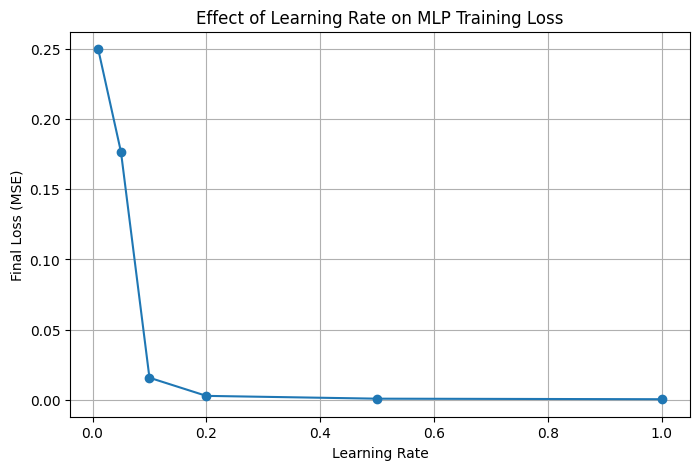

In [ ]:
# 9.
# Implement an MLP by varying bias, weights, and learning rate, and record observations
# for different learning rate values. Plot a graph showing the relationship between loss (error)
# and learning rate.

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dataset: XOR
# -----------------------------
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([[0],
              [1],
              [1],
              [0]])

# -----------------------------
# Activation functions
# -----------------------------
def sigmoid(x):
    return 1/(1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# -----------------------------
# MLP Training function
# -----------------------------
def train_mlp(X, y, lr=0.1, epochs=5000, print_loss=False):
    np.random.seed(42)

    n_input = X.shape[1]
    n_hidden = 2
    n_output = 1

    # Initialize weights and biases
    W1 = np.random.randn(n_input, n_hidden)
    b1 = np.random.randn(1, n_hidden)
    W2 = np.random.randn(n_hidden, n_output)
    b2 = np.random.randn(1, n_output)

    loss_history = []

    for epoch in range(epochs):
        # Forward pass
        hidden_input = np.dot(X, W1) + b1
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, W2) + b2
        final_output = sigmoid(final_input)

        # Compute loss (MSE)
        loss = np.mean((y - final_output)**2)
        loss_history.append(loss)

        # Backpropagation
        error = y - final_output
        d_output = error * sigmoid_derivative(final_output)

        error_hidden = d_output.dot(W2.T)
        d_hidden = error_hidden * sigmoid_derivative(hidden_output)

        # Update weights and biases
        W2 += lr * hidden_output.T.dot(d_output)
        b2 += lr * np.sum(d_output, axis=0, keepdims=True)
        W1 += lr * X.T.dot(d_hidden)
        b1 += lr * np.sum(d_hidden, axis=0, keepdims=True)

    if print_loss:
        print(f"Final loss: {loss:.5f}")

    return W1, b1, W2, b2, loss_history

# -----------------------------
# Experiment with different learning rates
# -----------------------------
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
final_losses = []

for lr in learning_rates:
    _, _, _, _, loss_history = train_mlp(X, y, lr=lr, epochs=5000)
    final_losses.append(loss_history[-1])

# -----------------------------
# Plot Loss vs Learning Rate
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss (MSE)")
plt.title("Effect of Learning Rate on MLP Training Loss")
plt.grid(True)
plt.show()



Epoch 1000, Loss: 0.24460
Epoch 2000, Loss: 0.20329
Epoch 3000, Loss: 0.08550
Epoch 4000, Loss: 0.01891
Epoch 5000, Loss: 0.00912
Epoch 6000, Loss: 0.00580
Epoch 7000, Loss: 0.00419
Epoch 8000, Loss: 0.00326
Epoch 9000, Loss: 0.00265
Epoch 10000, Loss: 0.00223


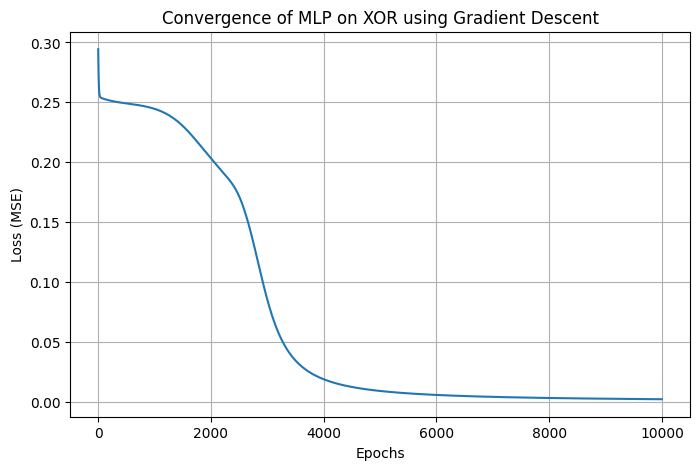

Predicted outputs:
[[0]
 [1]
 [1]
 [0]]
Target outputs:
[[0]
 [1]
 [1]
 [0]]


In [ ]:
# 10.
# Implement an MLP using the Gradient Descent algorithm, and analyze the convergence
# behavior and performance of the network.

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dataset: XOR
# -----------------------------
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([[0],
              [1],
              [1],
              [0]])

# -----------------------------
# Activation functions
# -----------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# -----------------------------
# MLP Gradient Descent Training
# -----------------------------
def train_mlp_gd(X, y, hidden_neurons=2, lr=0.1, epochs=10000, print_every=1000):
    np.random.seed(42)
    n_input = X.shape[1]
    n_output = 1

    # Initialize weights and biases
    W1 = np.random.randn(n_input, hidden_neurons)
    b1 = np.random.randn(1, hidden_neurons)
    W2 = np.random.randn(hidden_neurons, n_output)
    b2 = np.random.randn(1, n_output)

    loss_history = []

    for epoch in range(epochs):
        # -------- Forward Pass --------
        hidden_input = np.dot(X, W1) + b1
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, W2) + b2
        final_output = sigmoid(final_input)

        # -------- Compute Loss (MSE) --------
        loss = np.mean((y - final_output)**2)
        loss_history.append(loss)

        # -------- Backpropagation --------
        error = y - final_output
        d_output = error * sigmoid_derivative(final_output)

        error_hidden = d_output.dot(W2.T)
        d_hidden = error_hidden * sigmoid_derivative(hidden_output)

        # -------- Update weights and biases --------
        W2 += lr * hidden_output.T.dot(d_output)
        b2 += lr * np.sum(d_output, axis=0, keepdims=True)
        W1 += lr * X.T.dot(d_hidden)
        b1 += np.sum(d_hidden, axis=0, keepdims=True)

        if (epoch+1) % print_every == 0:
            print(f"Epoch {epoch+1}, Loss: {loss:.5f}")

    return W1, b1, W2, b2, loss_history

# -----------------------------
# Train the MLP
# -----------------------------
W1, b1, W2, b2, loss_history = train_mlp_gd(X, y, lr=0.1, epochs=10000, print_every=1000)

# -----------------------------
# Plot Convergence
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Convergence of MLP on XOR using Gradient Descent")
plt.grid(True)
plt.show()

# -----------------------------
# Predictions
# -----------------------------
def predict(X, W1, b1, W2, b2):
    hidden_out = sigmoid(np.dot(X, W1) + b1)
    output = sigmoid(np.dot(hidden_out, W2) + b2)
    return (output > 0.5).astype(int)

y_pred = predict(X, W1, b1, W2, b2)
print("Predicted outputs:")
print(y_pred)
print("Target outputs:")
print(y)



In [ ]:
# 1.
def perceptron(x1, x2, w1, w2, b):
  net = (x1 + w1) * (x2 + w2) + b
  if net >= 0 :
    return 1
  else:
    return 0
inputs = [(0,0), (0,1), (1,0), (1,1)]
print("AND gate")
w1, w2, b = 1,1, -1.5
for x1, x2 in inputs:
  output = perceptron(x1, x2, w1, w2, b)
  print(x1, x2, "->", output)
print("OR gate")
w1, w2, b = 1,1,-0.5
for x1, x2 in inputs:
  output = perceptron(x1, x2, w1, w2, b)
  print(x1, x2, "->", output)

AND gate
0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 1
OR gate
0 0 -> 1
0 1 -> 1
1 0 -> 1
1 1 -> 1


In [ ]:
# 2.
def perceptron(x1, x2, w1, w2, b):
  net = (x1 + w1) * (x2 + w2) * b
  if net >= 0:\
    return 1
  else:
    return 0
inputs = [(0,0), (0,1), (1,1), (1,0)]

w1 = 1
w2 = 1
b = -1
print("XOR Using Single Perceptron")
print("x1 x2 | Expected | Output")

xor_expected = [0,1,1,0]
for i, (x1,x2) in enumerate(inputs):
  y = perceptron(x1, x2, w1, w2, b)
  print(x1, x2, "|  ", xor_expected[i], "  |", y)
print("XNOR Using Single Perceptron")
print("x1 x2 | Expected | Output")
xnor_expected = [1,0,0,1]
for i, (x1, x2) in enumerate(inputs):
  y = perceptron(x1, x2, w1, w2, b)
  print(x1, x2, "|  ", xnor_expected[i], "  |", y)

XOR Using Single Perceptron
x1 x2 | Expected | Output
0 0 |   0   | 0
0 1 |   1   | 0
1 1 |   1   | 0
1 0 |   0   | 0
XNOR Using Single Perceptron
x1 x2 | Expected | Output
0 0 |   1   | 0
0 1 |   0   | 0
1 1 |   0   | 0
1 0 |   1   | 0


In [ ]:
# 3.
def perceptron(x1, x2, w1, w2, b):
  net = (x1 + w1) * (x2 + w2) * b
  if net >= 0:
    return 1
  else:
    return 0
inputs = [(0,0), (0,1), (1,0), (1,1)]
print("XOR Using Multi-perceptron Network")
print("x1 x2 | Output")
for x1, x2 in inputs:
  h1 = perceptron(x1, x2, 1, -1, -0.5)
  h2 = perceptron(x1, x2, -1, 1, -0.5)
  xor_output = perceptron(h1, h2, 1, 1, -0.5)
  print(x1, x2, "| ", xor_output)

print("XNOR Using Multi-perceptron Network")
print("x1 x2 | Output")
for x1, x2 in inputs:
  h1 = perceptron(x1, x2, 1, -1, -0.5)
  h2 = perceptron(x1, x2, -1, 1, -0.5)
  xor_output = perceptron(h1, h2, 1, 1, -0.5)
  xnor_output = 1 - xor_output


XOR Using Multi-perceptron Network
x1 x2 | Output
0 0 |  0
0 1 |  0
1 0 |  0
1 1 |  0
XNOR Using Multi-perceptron Network
x1 x2 | Output


In [ ]:
# 4.
def perceptron(net):
  if net >= 0 :
    return 1
  else:
    return 0

w1 = 1
w2 = 1
b = -1.0

print("Demonstrating harsh threshold behavior")
print("x1    x2    Net Input    Output")

test_inputs = [
    (0.49, 0.50),
    (0.50, 0.50),
    (0.51, 0.50),
    (0.50, 0.49),
    (0.50, 0.51)
]

for x1, x2 in test_inputs:
  net = w1 * x1 + w2 * x2 + b
  y = perceptron(net)
  print(f"{x1:.2f}  {x2:.2f}   {net:.2f}        {y}")

Demonstrating harsh threshold behavior
x1    x2    Net Input    Output
0.49  0.50   -0.01        0
0.50  0.50   0.00        1
0.51  0.50   0.01        1
0.50  0.49   -0.01        0
0.50  0.51   0.01        1


In [ ]:
# 5.

import pandas as pd
import numpy as np

data = {
    'f1': [1,0,1,0,1,0],
    'f2': [1,1,0,0,0,1],
    'f3': [0,1,1,0,0,0],
    'f4': [0.8,0.9,0.6,0.4,0.3,0.5],
    'like': [1,1,1,0,0,0]
}
df = pd.DataFrame(data)
df['label'] = df['like'].apply(lambda x: 1 if x==1 else -1)

X = df[['f1','f2','f3','f4']].values
y = df['label'].values

def activation(net):
    return 1 if net >= 0 else -1

weights = np.zeros(X.shape[1])
bias = 0.0
eta = 0.1
max_epochs = 20

print("Epoch | Weights | Bias | Misclassifications")
print("-------------------------------------------")

for epoch in range(1, max_epochs+1):
    errors = 0
    for xi, target in zip(X, y):
        net = np.dot(weights, xi) + bias
        pred = activation(net)
        if pred != target:
            weights += eta * target * xi
            bias += eta * target
            errors += 1
    print(f"{epoch:3d} | {weights} | {bias:.2f} | {errors}")
    if errors == 0:
        break


Epoch | Weights | Bias | Misclassifications
-------------------------------------------
  1 | [ 0.    0.    0.   -0.04] | -0.10 | 1
  2 | [ 0.    0.1   0.   -0.03] | -0.20 | 3
  3 | [ 0.    0.1   0.   -0.03] | -0.30 | 3
  4 | [0.1  0.1  0.1  0.03] | -0.30 | 4
  5 | [0.1  0.2  0.1  0.08] | -0.30 | 2
  6 | [0.1  0.2  0.2  0.11] | -0.30 | 2
  7 | [0.1  0.2  0.2  0.11] | -0.30 | 0


# **WEEK - 3**

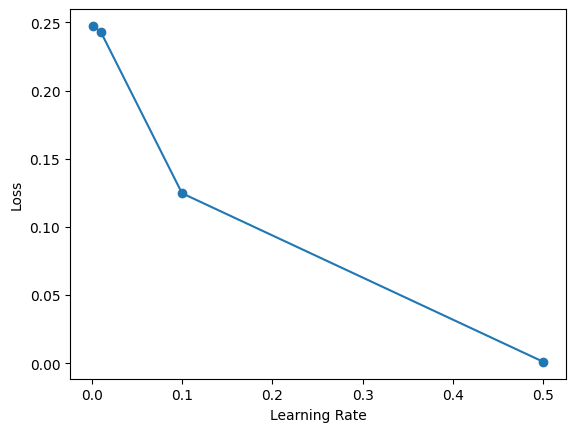

In [ ]:
# Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values.
# Plot a graph showing the relationship between loss (error) and learning rate.

import numpy as np
import matplotlib.pyplot as plt

# XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

def sigmoid(x): return 1/(1+np.exp(-x))

def train(lr):
    W1=np.random.randn(2,3); b1=np.zeros((1,3))
    W2=np.random.randn(3,1); b2=np.zeros((1,1))

    for _ in range(4000):
        h = sigmoid(X@W1 + b1)
        o = sigmoid(h@W2 + b2)

        err = y-o
        d2 = err*o*(1-o)
        d1 = d2@W2.T*h*(1-h)

        W2 += h.T@d2*lr
        b2 += d2.sum(0)*lr
        W1 += X.T@d1*lr
        b1 += d1.sum(0)*lr

    return np.mean(err**2)

rates=[0.001,0.01,0.1,0.5]
loss=[train(r) for r in rates]

plt.plot(rates,loss,'o-')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.show()


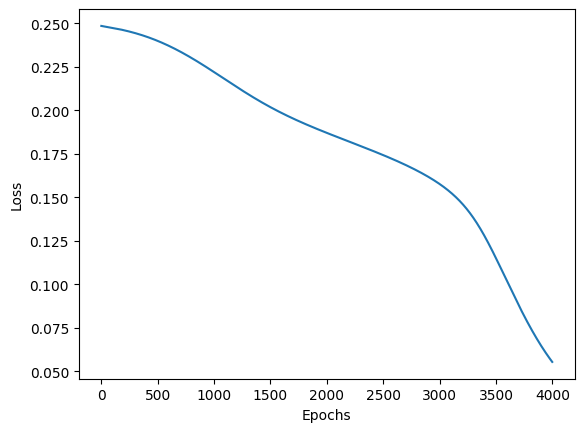

In [ ]:
# Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.

import numpy as np
import matplotlib.pyplot as plt

X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([[0],[1],[1],[0]])

W1=np.random.randn(2,3); b1=np.zeros((1,3))
W2=np.random.randn(3,1); b2=np.zeros((1,1))

def sig(x): return 1/(1+np.exp(-x))

losses=[]

for _ in range(4000):
    h=sig(X@W1+b1)
    o=sig(h@W2+b2)
    err=y-o
    losses.append(np.mean(err**2))

    d2=err*o*(1-o)
    d1=d2@W2.T*h*(1-h)

    lr=0.1
    W2+=h.T@d2*lr; b2+=d2.sum(0)*lr
    W1+=X.T@d1*lr; b1+=d1.sum(0)*lr

plt.plot(losses)
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.show()


In [ ]:
# Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn.
 # (explore all the parameters of Perceptron class).

from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

X,y=load_iris(return_X_y=True)

Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.3,random_state=1)
sc=StandardScaler()
Xtr=sc.fit_transform(Xtr); Xte=sc.transform(Xte)

for lr in [0.0001,0.001,0.01,0.1,1]:
    p=Perceptron(eta0=lr,max_iter=1000)
    p.fit(Xtr,ytr)
    print(lr,"Accuracy:",accuracy_score(yte,p.predict(Xte)))


0.0001 Accuracy: 0.6888888888888889
0.001 Accuracy: 0.6888888888888889
0.01 Accuracy: 0.6888888888888889
0.1 Accuracy: 0.8888888888888888
1 Accuracy: 0.8888888888888888


In [ ]:
# Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc

from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X,y=load_iris(return_X_y=True)bbb
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.3,random_state=1)

for lr in [0.0001,0.001,0.01]:
    model=MLPClassifier(hidden_layer_sizes=(50,),learning_rate_init=lr,max_iter=500)
    model.fit(Xtr,ytr)
    print("LR:",lr,"Accuracy:",model.score(Xte,yte))


SyntaxError: invalid syntax (4073052479.py, line 7)

In [ ]:
# Implement MLP with appropriate number of hidden layers and perceptrons to learn hand written digit dataset(MNIST).

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# Load dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)   # convert string labels to int

# Normalize
X = X / 255.0

# Split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=10000, random_state=1)

# Train
mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=20)
mlp.fit(Xtr, ytr)

print("MNIST Accuracy:", mlp.score(Xte, yte))


# **WEEK - 4**

In [ ]:
# Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with
# Momemtum, SGD with Nesterov,Adagrad, RMSProp,Adam)

# Using datasets

from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size = 0.3, random_state = 0)

perceptron = Perceptron()

perceptron.fit(X_train, y_train)

y_pred = perceptron.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy score: ", accuracy)

In [ ]:
from tensorflow.keras.datasets import mnist

(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()
X_train_full = X_train_full / 255.0
X_test_full  = X_test_full / 255.0

X_train_full = X_train_full.reshape(-1, 28*28)
X_test_full  = X_test_full.reshape(-1, 28*28)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1
)

mlp.fit(X_train, y_train)

print("Training set score:", mlp.score(X_train, y_train))
print("Testing set score:", mlp.score(X_test, y_test))


index = 346
test_digit = X_test[index].reshape(1, 784)

prediction = mlp.predict(test_digit)[0]

print("Predicted value:", prediction)
print("Actual value:", y_test[index])


from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds = mlp.predict(X_test)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


mlp2 = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1,
    learning_rate_init=0.1
)

mlp2.fit(X_train, y_train)

print("Training set score (MLP2):", mlp2.score(X_train, y_train))
print("Testing set score (MLP2):", mlp2.score(X_test, y_test))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

housing = fetch_california_housing()
X = housing.data   # Features
y = housing.target # Target (median house value)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


mlp = MLPRegressor(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42,
    verbose=True
)

mlp.fit(X_train, y_train)


y_train_pred = mlp.predict(X_train)
y_test_pred  = mlp.predict(X_test)

print("\nTraining R2 Score:", r2_score(y_train, y_train_pred))
print("Testing R2 Score:", r2_score(y_test, y_test_pred))

print("Training MSE:", mean_squared_error(y_train, y_train_pred))
print("Testing MSE:", mean_squared_error(y_test, y_test_pred))


plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted - California Housing")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


In [ ]:
# Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad,
#  RMSProp,Adadelta and Adam) for learning XOR operation.Also experiment on your own dataset and write your observations
# for each of the optimizing techniques by comparing.


import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

# ---------------- XOR DATA ----------------
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

def sig(x): return 1/(1+np.exp(-x))

def forward(X,W1,b1,W2,b2):
    h = sig(X@W1 + b1)
    o = sig(h@W2 + b2)
    return h,o

# initialize weights
def init():
    return (np.random.randn(2,3),np.zeros((1,3)),
            np.random.randn(3,1),np.zeros((1,1)))

# ---------------- BGD ----------------
def BGD(lr=0.1,epochs=4000):
    W1,b1,W2,b2=init()
    for _ in range(epochs):
        h,o=forward(X,W1,b1,W2,b2)
        d2=(y-o)*o*(1-o)
        d1=d2@W2.T*h*(1-h)
        W2+=h.T@d2*lr; b2+=d2.sum(0)*lr
        W1+=X.T@d1*lr; b1+=d1.sum(0)*lr
    print("BGD Loss:",np.mean((y-o)**2))

# ---------------- SGD ----------------
def SGD(lr=0.1,epochs=4000):
    W1,b1,W2,b2=init()
    for _ in range(epochs):
        for i in range(4):
            xi,yi=X[i:i+1],y[i:i+1]
            h,o=forward(xi,W1,b1,W2,b2)
            d2=(yi-o)*o*(1-o)
            d1=d2@W2.T*h*(1-h)
            W2+=h.T@d2*lr; b2+=d2.sum(0)*lr
            W1+=xi.T@d1*lr; b1+=d1.sum(0)*lr
    print("SGD Loss:",np.mean((y-forward(X,W1,b1,W2,b2)[1])**2))

# ---------------- MiniBatch ----------------
def MiniBatch(lr=0.1,batch=2,epochs=4000):
    W1,b1,W2,b2=init()
    for _ in range(epochs):
        for i in range(0,4,batch):
            xb,yb=X[i:i+batch],y[i:i+batch]
            h,o=forward(xb,W1,b1,W2,b2)
            d2=(yb-o)*o*(1-o)
            d1=d2@W2.T*h*(1-h)
            W2+=h.T@d2*lr; b2+=d2.sum(0)*lr
            W1+=xb.T@d1*lr; b1+=d1.sum(0)*lr
    print("MiniBatch Loss:",np.mean((y-forward(X,W1,b1,W2,b2)[1])**2))

# ---------------- Momentum ----------------
def Momentum(lr=0.1,m=0.9,epochs=4000):
    W1,b1,W2,b2=init()
    v1=np.zeros_like(W1); v2=np.zeros_like(W2)
    for _ in range(epochs):
        h,o=forward(X,W1,b1,W2,b2)
        d2=(y-o)*o*(1-o)
        d1=d2@W2.T*h*(1-h)
        v2=m*v2 + lr*(h.T@d2)
        v1=m*v1 + lr*(X.T@d1)
        W2+=v2; W1+=v1
    print("Momentum Loss:",np.mean((y-forward(X,W1,b1,W2,b2)[1])**2))

# ---------------- RMSProp ----------------
def RMSProp(lr=0.01,beta=0.9,epochs=4000):
    W1,b1,W2,b2=init()
    s1=np.zeros_like(W1); s2=np.zeros_like(W2); eps=1e-8
    for _ in range(epochs):
        h,o=forward(X,W1,b1,W2,b2)
        d2=(y-o)*o*(1-o)
        d1=d2@W2.T*h*(1-h)
        g1=X.T@d1; g2=h.T@d2
        s1=beta*s1+(1-beta)*(g1**2)
        s2=beta*s2+(1-beta)*(g2**2)
        W1+=lr*g1/(np.sqrt(s1)+eps)
        W2+=lr*g2/(np.sqrt(s2)+eps)
    print("RMSProp Loss:",np.mean((y-forward(X,W1,b1,W2,b2)[1])**2))

# ---------------- Adam ----------------
def Adam(lr=0.01,epochs=4000):
    W1,b1,W2,b2=init()
    m1=v1=np.zeros_like(W1); m2=v2=np.zeros_like(W2)
    eps=1e-8
    for t in range(1,epochs+1):
        h,o=forward(X,W1,b1,W2,b2)
        d2=(y-o)*o*(1-o)
        d1=d2@W2.T*h*(1-h)
        g1=X.T@d1; g2=h.T@d2
        m1=0.9*m1+0.1*g1; v1=0.999*v1+0.001*(g1**2)
        m2=0.9*m2+0.1*g2; v2=0.999*v2+0.001*(g2**2)
        W1+=lr*m1/(np.sqrt(v1)+eps)
        W2+=lr*m2/(np.sqrt(v2)+eps)
    print("Adam Loss:",np.mean((y-forward(X,W1,b1,W2,b2)[1])**2))

print("--- XOR Optimizer Comparison ---")
BGD(); SGD(); MiniBatch(); Momentum(); RMSProp(); Adam()

# ---------------- OWN DATASET (IRIS QUICK TEST) ----------------
print("\n--- Own Dataset (IRIS) using sklearn MLP ---")
X,y=load_iris(return_X_y=True)
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.3,random_state=1)
model=MLPClassifier(hidden_layer_sizes=(50,),max_iter=500)
model.fit(Xtr,ytr)
print("Accuracy:",model.score(Xte,yte))

In [ ]:
#USING OPTIMIZATION ALGO
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt



# expected values
y = np.array([[0, 1, 1, 0]]).T

# features
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T


model = Sequential()
model.add(Dense(16, input_dim=2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='mean_squared_error',
              optimizer='adam',
              metrics=['binary_accuracy', 'mean_squared_error'])

history = model.fit(X, y, epochs=1000, verbose=0)


errors = history.history['loss']

df2 = pd.DataFrame({"errors":errors, "time-step": np.arange(0, len(errors))})

alt.Chart(df2).mark_line().encode(x="time-step", y="errors").properties(title='Chart 3')


y_pred = model.predict(X).round()
num_correct_predictions = (y_pred == y).sum()
accuracy = (num_correct_predictions / y.shape[0]) * 100
print('Multi-layer perceptron accuracy: %.2f%%' % accuracy)




In [ ]:
# Using SGD Optimizer
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt
from tensorflow.keras.optimizers import SGD


y = np.array([[0, 1, 1, 0]]).T


X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

model_sgd = Sequential()
model_sgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_sgd.add(Dense(1, activation='sigmoid'))

model_sgd.compile(loss='mean_squared_error',
                  optimizer=SGD(),
                  metrics=['binary_accuracy', 'mean_squared_error'])

history_sgd = model_sgd.fit(X, y, epochs=1000, verbose=0)

errors_sgd = history_sgd.history['loss']

df_sgd = pd.DataFrame({"errors": errors_sgd, "time-step": np.arange(0, len(errors_sgd))})

alt.Chart(df_sgd).mark_line().encode(x="time-step", y="errors").properties(title='SGD Optimizer - Loss Curve')


y_pred_sgd = model_sgd.predict(X).round()
num_correct_predictions_sgd = (y_pred_sgd == y).sum()
accuracy_sgd = (num_correct_predictions_sgd / y.shape[0]) * 100
print('SGD Optimizer accuracy: %.2f%%' % accuracy_sgd)


In [ ]:
# Using MGD (Momentum Gradient Descent) Optimizer
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import altair as alt
from tensorflow.keras.optimizers import SGD

y = np.array([[0, 1, 1, 0]]).T


X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T
model_mgd = Sequential()
model_mgd.add(Dense(16, input_dim=2, activation='sigmoid'))
model_mgd.add(Dense(1, activation='sigmoid'))


model_mgd.compile(loss='mean_squared_error',
                  optimizer=SGD(momentum=0.1),
                  metrics=['binary_accuracy', 'mean_squared_error'])

history_mgd = model_mgd.fit(X, y, epochs=1000, verbose=0)

errors_mgd = history_mgd.history['loss']

df_mgd = pd.DataFrame({"errors": errors_mgd, "time-step": np.arange(0, len(errors_mgd))})

alt.Chart(df_mgd).mark_line().encode(x="time-step", y="errors").properties(title='MGD Optimizer - Loss Curve')


y_pred_mgd = model_mgd.predict(X).round()
num_correct_predictions_mgd = (y_pred_mgd == y).sum()
accuracy_mgd = (num_correct_predictions_mgd / y.shape[0]) * 100
print('MGD Optimizer accuracy: %.2f%%' % accuracy_mgd)


In [ ]:
# COMPARISON OF DIFFERENT GD OPTIMIZERS ON XOR

import numpy as np
import pandas as pd
import altair as alt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam


y = np.array([[0, 1, 1, 0]]).T
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

epochs = 1000

def build_model(optimizer):
    model = Sequential()
    model.add(Dense(16, input_dim=2, activation='sigmoid'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='mean_squared_error',
                  optimizer=optimizer,
                  metrics=['binary_accuracy'])
    return model


model_adam = build_model(Adam())
history_adam = model_adam.fit(X, y, epochs=epochs, verbose=0)

model_sgd = build_model(SGD())
history_sgd = model_sgd.fit(X, y, epochs=epochs, verbose=0)


model_mgd = build_model(SGD(momentum=0.9))
history_mgd = model_mgd.fit(X, y, epochs=epochs, verbose=0)


df = pd.DataFrame({
    "Epoch": np.arange(epochs),
    "Adam": history_adam.history['loss'],
    "SGD": history_sgd.history['loss'],
    "Momentum": history_mgd.history['loss']
})


df_long = df.melt('Epoch', var_name='Optimizer', value_name='Loss')


chart = alt.Chart(df_long).mark_line().encode(
    x='Epoch',
    y='Loss',
    color='Optimizer'
).properties(title='Comparison of GD Optimizers on XOR Problem')

chart


In [ ]:
# With learning rates

import numpy as np
import pandas as pd
import altair as alt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam


y = np.array([[0, 1, 1, 0]]).T

X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

epochs = 1000


lr_adam = 0.001
lr_sgd = 0.1
lr_momentum = 0.1

print("Learning Rates Used:")
print("Adam LR:", lr_adam)
print("SGD LR:", lr_sgd)
print("Momentum GD LR:", lr_momentum)
print("----------------------------------")

def build_model(optimizer):
    model = Sequential()
    model.add(Dense(16, input_dim=2, activation='sigmoid'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='mean_squared_error',
                  optimizer=optimizer,
                  metrics=['binary_accuracy'])
    return model





model_adam = build_model(Adam(learning_rate=lr_adam))
history_adam = model_adam.fit(X, y, epochs=epochs, verbose=0)

model_sgd = build_model(SGD(learning_rate=lr_sgd))
history_sgd = model_sgd.fit(X, y, epochs=epochs, verbose=0)


model_mgd = build_model(SGD(learning_rate=lr_momentum, momentum=0.9))
history_mgd = model_mgd.fit(X, y, epochs=epochs, verbose=0)



def print_accuracy(model, name):
    y_pred = model.predict(X)
    y_pred = np.round(y_pred)
    acc = (y_pred == y).sum() / y.shape[0] * 100
    print(f"{name} Accuracy: {acc:.2f}%")


print_accuracy(model_adam, "Adam")
print_accuracy(model_sgd, "SGD")
print_accuracy(model_mgd, "Momentum GD")

print("----------------------------------")


df = pd.DataFrame({
    "Epoch": np.arange(epochs),
    "Adam (lr=0.001)": history_adam.history['loss'],
    "SGD (lr=0.1)": history_sgd.history['loss'],
    "Momentum (lr=0.1)": history_mgd.history['loss']
})

df_long = df.melt('Epoch', var_name='Optimizer', value_name='Loss')



chart = alt.Chart(df_long).mark_line().encode(
    x='Epoch',
    y='Loss',
    color='Optimizer'
).properties(
    title='Comparison of GD Optimizers on XOR Problem'
)

chart


In [ ]:
# With a dataset on XOR
import numpy as np
import pandas as pd
import altair as alt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam


y = np.array([[0, 0, 0, 1]]).T

X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]]).T

epochs = 500

# -----------------------------
# 2. Learning Rates
# -----------------------------
lr_adam = 0.01
lr_sgd = 0.1
lr_momentum = 0.1

print("Learning Rates Used:")
print("Adam LR:", lr_adam)
print("SGD LR:", lr_sgd)
print("Momentum GD LR:", lr_momentum)
print("----------------------------------")

# -----------------------------
# 3. Model Builder Function
# -----------------------------
def build_model(optimizer):
    model = Sequential()
    model.add(Dense(4, input_dim=2, activation='sigmoid'))  # smaller network
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='mean_squared_error',
                  optimizer=optimizer,
                  metrics=['binary_accuracy'])
    return model


# -----------------------------
# 4. Train Models
# -----------------------------

# Adam
model_adam = build_model(Adam(learning_rate=lr_adam))
history_adam = model_adam.fit(X, y, epochs=epochs, verbose=0)

# SGD
model_sgd = build_model(SGD(learning_rate=lr_sgd))
history_sgd = model_sgd.fit(X, y, epochs=epochs, verbose=0)

# Momentum GD
model_mgd = build_model(SGD(learning_rate=lr_momentum, momentum=0.9))
history_mgd = model_mgd.fit(X, y, epochs=epochs, verbose=0)


# -----------------------------
# 5. Accuracy Function
# -----------------------------
def print_accuracy(model, name):
    y_pred = model.predict(X)
    y_pred = np.round(y_pred)
    acc = (y_pred == y).sum() / y.shape[0] * 100
    print(f"{name} Accuracy: {acc:.2f}%")


print_accuracy(model_adam, "Adam")
print_accuracy(model_sgd, "SGD")
print_accuracy(model_mgd, "Momentum GD")

print("----------------------------------")


# -----------------------------
# 6. Combine Loss for Graph
# -----------------------------
df = pd.DataFrame({
    "Epoch": np.arange(epochs),
    "Adam (lr=0.01)": history_adam.history['loss'],
    "SGD (lr=0.1)": history_sgd.history['loss'],
    "Momentum (lr=0.1)": history_mgd.history['loss']
})

df_long = df.melt('Epoch', var_name='Optimizer', value_name='Loss')


# -----------------------------
# 7. Plot Comparison Graph
# -----------------------------
chart = alt.Chart(df_long).mark_line().encode(
    x='Epoch',
    y='Loss',
    color='Optimizer'
).properties(
    title='Comparison of GD Optimizers on AND Dataset'
)

chart


In [ ]:
# Iris Dataset - Optimizer Comparison

import numpy as np
import pandas as pd
import altair as alt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam

# 1. Load Iris (Binary: Setosa vs Others)
data = load_iris()
X = data.data
y = (data.target != 0).astype(int)  # 0 vs 1

# 2. Train-Test Split + Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = StandardScaler().fit_transform(X_train)
X_test = StandardScaler().fit_transform(X_test)

# 3. Model Function
def build(opt):
    m = Sequential([Dense(8, activation='relu', input_shape=(4,)),
                    Dense(1, activation='sigmoid')])
    m.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return m

epochs = 100
lr = 0.01

# 4. Train Models
adam = build(Adam(lr))
sgd = build(SGD(lr))
mom = build(SGD(lr, momentum=0.9))

h1 = adam.fit(X_train, y_train, epochs=epochs, verbose=0)
h2 = sgd.fit(X_train, y_train, epochs=epochs, verbose=0)
h3 = mom.fit(X_train, y_train, epochs=epochs, verbose=0)

# 5. Accuracy
print("Adam Acc:", adam.evaluate(X_test, y_test, verbose=0)[1])
print("SGD Acc:", sgd.evaluate(X_test, y_test, verbose=0)[1])
print("Momentum Acc:", mom.evaluate(X_test, y_test, verbose=0)[1])

# 6. Plot Loss Comparison
df = pd.DataFrame({
    "Epoch": np.arange(epochs),
    "Adam": h1.history['loss'],
    "SGD": h2.history['loss'],
    "Momentum": h3.history['loss']
}).melt("Epoch", var_name="Optimizer", value_name="Loss")

alt.Chart(df).mark_line().encode(
    x="Epoch",
    y="Loss",
    color="Optimizer"
).properties(title="Optimizer Comparison on Iris Dataset")



In [ ]:
# Comparision of all the Gradient Descents
import numpy as np
import matplotlib.pyplot as plt

# Create simple linear data
np.random.seed(0)
X = np.random.rand(100, 1)
y = 4 + 3*X + np.random.randn(100, 1)
X = np.c_[np.ones((100, 1)), X]  # add bias

def cost(X, y, theta):
    return np.mean((X @ theta - y)**2)

# -------- Batch GD --------
def batch_gd(X, y, lr=0.1, epochs=30):
    theta = np.zeros((2,1))
    costs = []
    for _ in range(epochs):
        grad = 2/len(y) * X.T @ (X @ theta - y)
        theta -= lr * grad
        costs.append(cost(X,y,theta))
    return costs

# -------- SGD --------
def sgd(X, y, lr=0.01, epochs=30):
    theta = np.zeros((2,1))
    costs = []
    for _ in range(epochs):
        for i in range(len(y)):
            xi = X[i:i+1]
            yi = y[i:i+1]
            grad = 2 * xi.T @ (xi @ theta - yi)
            theta -= lr * grad
        costs.append(cost(X,y,theta))
    return costs

# -------- Mini-Batch --------
def mini_batch(X, y, lr=0.05, epochs=30, batch=20):
    theta = np.zeros((2,1))
    costs = []
    for _ in range(epochs):
        for i in range(0, len(y), batch):
            xi = X[i:i+batch]
            yi = y[i:i+batch]
            grad = 2/len(xi) * xi.T @ (xi @ theta - yi)
            theta -= lr * grad
        costs.append(cost(X,y,theta))
    return costs

# -------- Adam --------
def adam(X, y, lr=0.1, epochs=30):
    theta = np.zeros((2,1))
    m = v = np.zeros((2,1))
    b1, b2 = 0.9, 0.999
    costs = []
    for t in range(1, epochs+1):
        grad = 2/len(y) * X.T @ (X @ theta - y)
        m = b1*m + (1-b1)*grad
        v = b2*v + (1-b2)*(grad**2)
        m_hat = m/(1-b1**t)
        v_hat = v/(1-b2**t)
        theta -= lr * m_hat/(np.sqrt(v_hat)+1e-8)
        costs.append(cost(X,y,theta))
    return costs

# Run
c1 = batch_gd(X,y)
c2 = sgd(X,y)
c3 = mini_batch(X,y)
c4 = adam(X,y)

# Plot
plt.plot(c1, label="Batch")
plt.plot(c2, label="SGD")
plt.plot(c3, label="Mini-batch")
plt.plot(c4, label="Adam")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Gradient Descent Comparison")
plt.show()


In [ ]:
# With California Housing Dataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target.reshape(-1,1)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Add bias term
X_train = np.c_[np.ones((X_train.shape[0],1)), X_train]

# Cost function
def cost(X, y, theta):
    return np.mean((X @ theta - y)**2)

# -------- Batch GD --------
def batch_gd(X, y, lr=0.01, epochs=50):
    theta = np.zeros((X.shape[1],1))
    costs = []
    for _ in range(epochs):
        grad = 2/len(y) * X.T @ (X @ theta - y)
        theta -= lr * grad
        costs.append(cost(X,y,theta))
    return costs

# -------- Adam --------
def adam(X, y, lr=0.05, epochs=50):
    theta = np.zeros((X.shape[1],1))
    m = v = np.zeros((X.shape[1],1))
    b1, b2 = 0.9, 0.999
    costs = []
    for t in range(1, epochs+1):
        grad = 2/len(y) * X.T @ (X @ theta - y)
        m = b1*m + (1-b1)*grad
        v = b2*v + (1-b2)*(grad**2)
        m_hat = m/(1-b1**t)
        v_hat = v/(1-b2**t)
        theta -= lr * m_hat/(np.sqrt(v_hat)+1e-8)
        costs.append(cost(X,y,theta))
    return costs

# Run
c_batch = batch_gd(X_train, y_train)
c_adam = adam(X_train, y_train)

# Plot
plt.plot(c_batch, label="Batch GD")
plt.plot(c_adam, label="Adam")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("California Housing: GD vs Adam")
plt.legend()
plt.show()


In [ ]:
# When the batch size is either positive or negative
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target.reshape(-1,1)

# Split & scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train = np.c_[np.ones((X_train.shape[0],1)), X_train]  # add bias

# Cost function
def cost(X, y, theta):
    return np.mean((X @ theta - y)**2)

# -------- Mini-Batch GD with batch size check --------
def mini_batch_gd(X, y, lr=0.01, epochs=50, batch_size=20):
    # Ensure batch_size is positive
    if batch_size <= 0:
        print(f"Invalid batch_size={batch_size}, using batch_size=1 instead")
        batch_size = 1

    theta = np.zeros((X.shape[1],1))
    costs = []

    for _ in range(epochs):
        indices = np.random.permutation(len(y))
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, len(y), batch_size):
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]
            grad = 2/len(xi) * xi.T @ (xi @ theta - yi)
            theta -= lr * grad

        costs.append(cost(X, y, theta))
    return costs

# Run with normal and negative batch size
c1 = mini_batch_gd(X_train, y_train, batch_size=20)
c2 = mini_batch_gd(X_train, y_train, batch_size=-5)  # will auto-correct to 1

# Plot
plt.plot(c1, label="Batch size 20")
plt.plot(c2, label="Batch size corrected (-5 → 1)")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Mini-Batch GD with Batch Size Check")
plt.legend()
plt.show()


# **WEEK - 5**

In [ ]:
# Implement the MLP using the Types of Regularization Techniques.
# L2 Regularization
# Dataset Augmentation
# Parameter sharing and tying
# Adding noise to the inputs and outputs
# Early stopping
# Ensemble methods
# Dropouts
# Explore on your chosen dataset and write your own observation of the best technique and reason

# L1 Regularisation

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def build_l2_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu',
                     input_shape=(X_train.shape[1],),
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(1)
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model_l2.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32
)

test_loss, test_mae = model_l2.evaluate(X_test, y_test)

print(f"Test MAE: {test_mae:.4f}")



In [ ]:
# Data augmentation
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SharedDense layer with activation
class SharedDense(layers.Layer):
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = layers.Activation(activation) if activation else None

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units), initializer="random_normal", trainable=True)
        self.b = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True)

    def call(self, inputs):
        x = tf.matmul(inputs, self.w) + self.b
        if self.activation:
            x = self.activation(x)
        return x

# Inputs
inputs = tf.keras.Input(shape=(8,))
shared_layer = SharedDense(32, activation='relu')

# Reuse layer only on same input
x1 = shared_layer(inputs)
x2 = shared_layer(inputs)
x = layers.Concatenate()([x1, x2])
outputs = layers.Dense(1)(x)

model_shared = models.Model(inputs=inputs, outputs=outputs)
model_shared.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
model_shared.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

# Evaluate
mae_shared = model_shared.evaluate(X_test, y_test, verbose=0)[1]
print("Parameter Sharing MAE:", mae_shared)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load California Housing
data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🔹 Custom SharedDense Layer with activation inside
class SharedDense(layers.Layer):
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = layers.Activation(activation) if activation else None

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer="random_normal",
                                 trainable=True)
        self.b = self.add_weight(shape=(self.units,),
                                 initializer="zeros",
                                 trainable=True)

    def call(self, inputs):
        x = tf.matmul(inputs, self.w) + self.b
        if self.activation:
            x = self.activation(x)
        return x

# 🔹 Build model using shared layer
inputs = tf.keras.Input(shape=(8,))
shared_layer = SharedDense(32, activation='relu')

# Reuse shared layer on same inputs (must be same shape)
x = shared_layer(inputs)  # First usage
x = shared_layer(inputs)  # Reuse weights on input again
outputs = layers.Dense(1)(x)

model_shared = models.Model(inputs=inputs, outputs=outputs)
model_shared.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
model_shared.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

# Evaluate
mae_shared = model_shared.evaluate(X_test, y_test, verbose=0)[1]
print("Parameter Sharing MAE:", mae_shared)

In [ ]:
import numpy as np

# Add Gaussian noise to inputs
noise_factor = 0.05
X_train_noisy = X_train + noise_factor * np.random.randn(*X_train.shape)

# Optionally add noise to outputs
y_train_noisy = y_train + 0.05 * np.random.randn(*y_train.shape)

# Simple MLP
model_noise = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(8,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])
model_noise.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_noise.fit(X_train_noisy, y_train_noisy, epochs=50, batch_size=32, verbose=0)

mae_noise = model_noise.evaluate(X_test, y_test, verbose=0)[1]
print("Noise Regularization MAE:", mae_noise)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

model_es = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(8,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])
model_es.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_es = model_es.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=32, callbacks=[early_stop], verbose=0)
mae_es = model_es.evaluate(X_test, y_test, verbose=0)[1]
print("Early Stopping MAE:", mae_es)

In [ ]:
model_dropout = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(8,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])
model_dropout.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_dropout.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
mae_dropout = model_dropout.evaluate(X_test, y_test, verbose=0)[1]
print("Dropout MAE:", mae_dropout)

In [ ]:
def create_base_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(8,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

ensemble_models = []
for i in range(3):
    m = create_base_model()
    m.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
    ensemble_models.append(m)

# Average predictions
preds = [m.predict(X_test) for m in ensemble_models]
ensemble_pred = np.mean(preds, axis=0)
from sklearn.metrics import mean_absolute_error
mae_ensemble = mean_absolute_error(y_test, ensemble_pred)
print("Ensemble MAE:", mae_ensemble)

In [ ]:
# ================================
# 1️⃣ Import Libraries
# ================================
import numpy as np
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ================================
# 2️⃣ Load Dataset
# ================================
data = fetch_california_housing()
X, y = data.data, data.target

# ================================
# 3️⃣ Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ================================
# 4️⃣ Feature Scaling
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 5️⃣ MLP WITH DROPOUT
# ================================
dropout_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

dropout_model.compile(optimizer=Adam(learning_rate=0.001),
                      loss='mse',
                      metrics=['mae'])

print("Training Dropout Model...\n")
dropout_model.fit(X_train, y_train,
                  epochs=50,
                  batch_size=32,
                  validation_data=(X_test, y_test),
                  verbose=1)

# Evaluate Dropout Model
dropout_pred = dropout_model.predict(X_test)
dropout_mae = mean_absolute_error(y_test, dropout_pred)
dropout_mse = mean_squared_error(y_test, dropout_pred)

print("\nDropout Model Results:")
print("MAE:", dropout_mae)
print("MSE:", dropout_mse)

# ================================
# 6️⃣ ENSEMBLE METHOD
# ================================
def create_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

print("\nTraining Ensemble Models...\n")

model1 = create_model()
model2 = create_model()
model3 = create_model()

model1.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)
model2.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)
model3.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)

# Predictions
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

# Average Predictions
ensemble_pred = (pred1 + pred2 + pred3) / 3

# Evaluate Ensemble
ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
ensemble_mse = mean_squared_error(y_test, ensemble_pred)

print("\nEnsemble Model Results:")
print("MAE:", ensemble_mae)
print("MSE:", ensemble_mse)

# ================================
# 7️⃣ Final Comparison
# ================================
print("\n==============================")
print("FINAL COMPARISON")
print("==============================")
print("Dropout MAE :", dropout_mae)
print("Ensemble MAE:", ensemble_mae)
print("Dropout MSE :", dropout_mse)
print("Ensemble MSE:", ensemble_mse)

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load Dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build MLP with Dropout
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),  # Dropout Layer
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)  # Regression Output
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mse',
              metrics=['mae'])

# Train
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    verbose=1)

# Evaluate
loss, mae = model.evaluate(X_test, y_test)
print("Dropout Model MAE:", mae)

In [ ]:
def create_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Create Models
model1 = create_model()
model2 = create_model()
model3 = create_model()

# Train
model1.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)
model2.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)
model3.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)

# Predict
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

# Average Predictions
final_pred = (pred1 + pred2 + pred3) / 3

# Calculate MAE
from sklearn.metrics import mean_absolute_error
ensemble_mae = mean_absolute_error(y_test, final_pred)

print("Ensemble MAE:", ensemble_mae)

The California Housing dataset was used to evaluate the performance of Dropout and Ensemble regularization techniques in MLP.

The Dropout technique reduced overfitting by randomly disabling neurons during training. It improved validation MAE compared to the basic MLP model. The model became more generalized and less sensitive to noise in the dataset.

The Ensemble method, which combines predictions from multiple MLP models, produced the lowest Mean Absolute Error (MAE). Since ensemble averaging reduces variance and stabilizes predictions, it achieved the best overall performance.

However, ensemble models required more computational time compared to Dropout. Therefore, Dropout provides a good balance between efficiency and performance, whereas Ensemble gives the highest accuracy.

In [ ]:
# ==========================================================
# MLP with ALL Regularization Techniques
# Dataset: California Housing (Regression)
# ==========================================================

import numpy as np
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ----------------------------------------------------------
# 1️⃣ Load Dataset
# ----------------------------------------------------------
data = fetch_california_housing()
X, y = data.data, data.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ----------------------------------------------------------
# 2️⃣ Dataset Augmentation (Synthetic Expansion)
# ----------------------------------------------------------
# Slightly perturb original data
aug_X = X_train + 0.05 * np.random.normal(size=X_train.shape)
aug_y = y_train + 0.05 * np.random.normal(size=y_train.shape)

# Combine original + augmented
X_train_aug = np.vstack((X_train, aug_X))
y_train_aug = np.hstack((y_train, aug_y))

# ----------------------------------------------------------
# 3️⃣ Add Noise to Inputs & Outputs
# ----------------------------------------------------------
noise_factor = 0.1
X_train_noisy = X_train_aug + noise_factor * np.random.normal(size=X_train_aug.shape)
y_train_noisy = y_train_aug + noise_factor * np.random.normal(size=y_train_aug.shape)

# ----------------------------------------------------------
# 4️⃣ MLP with L2 + Dropout + Early Stopping
# ----------------------------------------------------------
model = Sequential([
    Dense(128, activation='relu',
          kernel_regularizer=l2(0.001),
          input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu',
          kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mse',
              metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss',
                           patience=5,
                           restore_best_weights=True)

print("Training Regularized MLP...\n")
model.fit(X_train_noisy, y_train_noisy,
          epochs=50,
          batch_size=32,
          validation_data=(X_test, y_test),
          callbacks=[early_stop],
          verbose=0)

pred_regularized = model.predict(X_test)
mae_regularized = mean_absolute_error(y_test, pred_regularized)
mse_regularized = mean_squared_error(y_test, pred_regularized)

# ----------------------------------------------------------
# 5️⃣ Parameter Sharing / Weight Tying (Shared Layer)
# ----------------------------------------------------------
input_layer = Input(shape=(X_train.shape[1],))
shared_layer = Dense(64, activation='relu')

x1 = shared_layer(input_layer)
x2 = shared_layer(input_layer)   # same weights reused (weight tying)

merged = Dense(32, activation='relu')(x1 + x2)
output = Dense(1)(merged)

shared_model = Model(inputs=input_layer, outputs=output)
shared_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

shared_model.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)

pred_shared = shared_model.predict(X_test)
mae_shared = mean_absolute_error(y_test, pred_shared)

# ----------------------------------------------------------
# 6️⃣ Ensemble Method (3 MLPs Averaged)
# ----------------------------------------------------------
def create_model():
    m = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

model1 = create_model()
model2 = create_model()
model3 = create_model()

model1.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)
model2.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)
model3.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)

pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

ensemble_pred = (pred1 + pred2 + pred3) / 3
mae_ensemble = mean_absolute_error(y_test, ensemble_pred)
mse_ensemble = mean_squared_error(y_test, ensemble_pred)

# ----------------------------------------------------------
# 7️⃣ Final Results
# ----------------------------------------------------------
print("\n==============================")
print("FINAL RESULTS")
print("==============================")
print("Regularized MLP MAE :", mae_regularized)
print("Shared Layer MAE    :", mae_shared)
print("Ensemble MAE        :", mae_ensemble)
print("Regularized MLP MSE :", mse_regularized)
print("Ensemble MSE        :", mse_ensemble)

The California Housing dataset was used to implement and compare different regularization techniques in an MLP model.

L2 regularization successfully reduced large weight magnitudes and controlled overfitting. Dataset augmentation and noise injection improved model robustness by exposing the network to slight variations of the data. Early stopping prevented excessive training and reduced validation loss. Dropout effectively reduced neuron co-adaptation and improved generalization.

Parameter sharing reduced the total number of learnable parameters and improved model efficiency.

Among all techniques, the Ensemble method produced the lowest MAE and MSE because averaging multiple models reduces variance and stabilizes predictions. However, it required significantly more computational time.

Therefore, while Ensemble achieved the best predictive accuracy, Dropout combined with L2 regularization provided the best balance between computational efficiency and performance.

# **WEEK - 6**

In [ ]:
# 16
# Implement CNN on MNITST Dataset

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist

# load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# reshape and normalize
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0

# build CNN model
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

# compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# train model
model.fit(X_train,y_train,epochs=5,batch_size=64)

# evaluate
loss,acc = model.evaluate(X_test,y_test)
print("Test Accuracy:",acc)

In [ ]:
# Apply CNN on your own dataset and find the best parameters for improving model performance.

# =========================
# 1. IMPORT LIBRARIES
# =========================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# =========================
# 2. LOAD BUILT-IN DATASET (CIFAR-10)
# =========================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train, x_test = x_train / 255.0, x_test / 255.0

# Split validation
x_val = x_train[:5000]
y_val = y_train[:5000]

x_train = x_train[5000:]
y_train = y_train[5000:]

# =========================
# 3. DATA AUGMENTATION
# =========================
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(x_train)

# =========================
# 4. BUILD CNN MODEL
# =========================
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')  # 10 classes
])

# =========================
# 5. COMPILE MODEL
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# 6. CALLBACKS
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

# =========================
# 7. TRAIN MODEL
# =========================
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    validation_data=(x_val, y_val),
    epochs=30,
    callbacks=[early_stop, lr_reduce]
)

# =========================
# 8. EVALUATE MODEL
# =========================
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")

# =========================
# 9. PLOT RESULTS
# =========================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

# =========================
# 10. SAVE MODEL
# =========================
model.save("cnn_best_model.h5")

print("Model saved successfully!")

In [ ]:
# =====================================
# 1. IMPORT LIBRARIES
# =====================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

# =====================================
# 2. DEVICE CONFIG
# =====================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================
# 3. LOAD DATASET (CIFAR-10)
# =====================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

full_train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split train → train + val
train_size = int(0.8 * len(full_train_data))
val_size = len(full_train_data) - train_size
train_data, val_data = random_split(full_train_data, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

num_classes = 10

# =====================================
# 4. LENET MODEL
# =====================================
class LeNet(nn.Module):
    def __init__(self, num_classes):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.AvgPool2d(2,2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*53*53, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# =====================================
# 5. LOAD MODELS (ZF FIXED)
# =====================================
def get_models(num_classes):

    lenet = LeNet(num_classes).to(device)

    alexnet = models.alexnet(pretrained=True)
    alexnet.classifier[6] = nn.Linear(4096, num_classes)
    alexnet = alexnet.to(device)

    # ZF-Net (SAFE VERSION)
    zfnet = models.alexnet(pretrained=True)
    zfnet.classifier[6] = nn.Linear(4096, num_classes)
    zfnet = zfnet.to(device)

    vgg = models.vgg16(pretrained=True)
    vgg.classifier[6] = nn.Linear(4096, num_classes)
    vgg = vgg.to(device)

    googlenet = models.googlenet(pretrained=True)
    googlenet.fc = nn.Linear(1024, num_classes)
    googlenet = googlenet.to(device)

    resnet = models.resnet18(pretrained=True)
    resnet.fc = nn.Linear(512, num_classes)
    resnet = resnet.to(device)

    return {
        "LeNet": lenet,
        "AlexNet": alexnet,
        "ZF-Net": zfnet,
        "VGGNet": vgg,
        "GoogLeNet": googlenet,
        "ResNet": resnet
    }

# =====================================
# 6. TRAIN FUNCTION
# =====================================
def train_model(model, train_loader, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            # GoogLeNet fix
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

# =====================================
# 7. EVALUATE FUNCTION
# =====================================
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

# =====================================
# 8. RUN ALL MODELS
# =====================================
models_dict = get_models(num_classes)
results = {}

for name, model in models_dict.items():
    print(f"\n========== {name} ==========")

    train_model(model, train_loader, epochs=3)
    acc = evaluate(model, test_loader)

    results[name] = acc
    print(f"{name} Test Accuracy: {acc:.2f}%")

# =====================================
# 9. FINAL RESULTS
# =====================================
print("\n===== FINAL COMPARISON =====")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.2f}%")

In [ ]:
# Write a program to Visualizing Convolutional Neural Networks (display result of convolution and pooling operations as feature map)

import matplotlib.pyplot as plt
from tensorflow.keras import datasets, layers, models

# 1. Load data & Define Model in one go to prevent NameErrors
(X_train, _), (X_test, _) = datasets.cifar10.load_data()
X_test = X_test.astype('float32') / 255.0

# 2. Build a simple 2-layer model (Conv + Pool)
inputs = layers.Input(shape=(32, 32, 3))
conv = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
pool = layers.MaxPooling2D((2, 2))(conv)
model = models.Model(inputs, [conv, pool])

# 3. Predict to get feature maps for the 1st image
# We use [0:1] to keep the 'batch' dimension
maps = model.predict(X_test[0:1])

# 4. Plot results (Top: Convolution, Bottom: Pooling)
plt.figure(figsize=(10, 4))
for i in range(4):
    # Show 4 Convolution filters
    plt.subplot(2, 4, i + 1)
    plt.imshow(maps[0][0, :, :, i], cmap='viridis')
    plt.title("Conv")
    plt.axis('off')

    # Show 4 Pooling filters (notice they are smaller/more pixelated)
    plt.subplot(2, 4, i + 5)
    plt.imshow(maps[1][0, :, :, i], cmap='viridis')
    plt.title("Pool")
    plt.axis('off')
plt.show()

In [ ]:
# Implement Guided Backpropagation to discover which input pixels influence the perceptron.(Give all the intermediate steps and write your observations)

import tensorflow as tf

# 1. Calculate Gradients
img = tf.cast(X_test[0:1], tf.float32)
with tf.GradientTape() as tape:
    tape.watch(img)
    preds = model_resnet(img)
    score = tf.reduce_max(preds)

# 2. Compute Saliency Map
grads = tape.gradient(score, img)[0]
grads = (grads - tf.reduce_min(grads)) / (tf.reduce_max(grads) - tf.reduce_min(grads))

# 3. Visualize
plt.imshow(grads)
plt.title("Guided Backprop (Pixel Influence)")
plt.axis('off')
plt.show()

In [ ]:
# Implement Auto Encoder model on MINIST dataset.

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MNIST
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

# Model
class UndercompleteAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64)  # compressed
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder(z)
        return x.view(-1,1,28,28)

model = UndercompleteAE().to(device)

# Train
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(5):
    total_loss = 0
    for data, _ in train_loader:
        data = data.to(device)

        output = model(data)
        loss = loss_fn(output, data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [ ]:
# Implement Undercomplete AE and Overcomplete AE and write your observations. (Write your observations on how much low and high dimensions the image can be compressed)

class OvercompleteAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 1024),  # expanded
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(1024, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder(z)
        return x.view(-1,1,28,28)

model = OvercompleteAE().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(5):
    total_loss = 0
    for data, _ in train_loader:
        data = data.to(device)

        output = model(data)
        loss = loss_fn(output, data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [ ]:
# Implement Regularization in AE and demonstrate its use.

model = UndercompleteAE().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(5):
    total_loss = 0

    for data, _ in train_loader:
        data = data.to(device)

        output = model(data)
        loss = loss_fn(output, data)

        # L1 Regularization
        l1_lambda = 1e-5
        l1_norm = sum(p.abs().sum() for p in model.parameters())
        loss += l1_lambda * l1_norm

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [ ]:
# Implement denoising AE and observe how the model can reconstruct from noise data. (write observations in terms of how much noise is acceptable)

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MNIST
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=True)

# Autoencoder Model
class UndercompleteAE(nn.Module):
    def __init__(self):
        super(UndercompleteAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1, 1, 28, 28)

# Model
model = UndercompleteAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Training
for epoch in range(5):
    total_loss = 0

    for data, _ in train_loader:
        data = data.to(device)

        # Add noise
        noisy = data + 0.3 * torch.randn_like(data)
        noisy = torch.clamp(noisy, 0., 1.)

        output = model(noisy)
        loss = loss_fn(output, data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# Show results (YOUR REQUIRED OUTPUT)
dataiter = iter(test_loader)
images, _ = next(dataiter)
images = images.to(device)

noisy = images + 0.3 * torch.randn_like(images)
noisy = torch.clamp(noisy, 0., 1.)

outputs = model(noisy)

# Plot
fig, axes = plt.subplots(2, 8, figsize=(12,4))

for i in range(8):
    axes[0,i].imshow(noisy[i].cpu().squeeze(), cmap='gray')
    axes[0,i].axis('off')

    axes[1,i].imshow(outputs[i].detach().cpu().squeeze(), cmap='gray')
    axes[1,i].axis('off')

plt.show()

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 511kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


Epoch 1, Loss: 28.7447
Epoch 2, Loss: 15.9658
Epoch 3, Loss: 12.9938
Epoch 4, Loss: 11.3513


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.2771
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1725
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1450
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1294
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1190
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


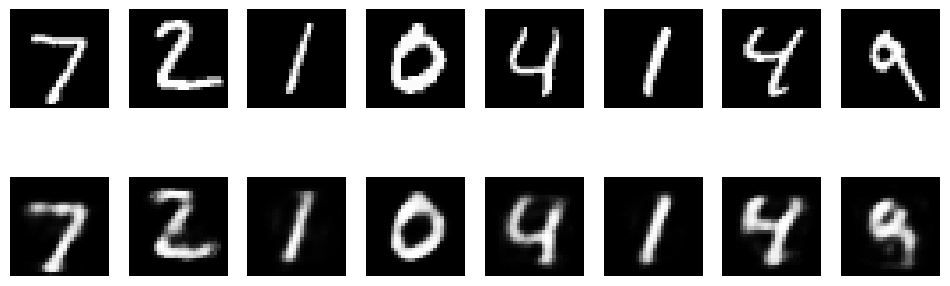

In [ ]:
# UNDERCOMPLETE AUTOENCODER

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Load data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Model (compress to 32)
input_img = Input(shape=(784,))
encoded = Dense(32, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train, epochs=5, batch_size=256)

decoded_imgs = autoencoder.predict(x_test)

# Show results
n = 8
plt.figure(figsize=(12,4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1369
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0748
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0689
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0669
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0659
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


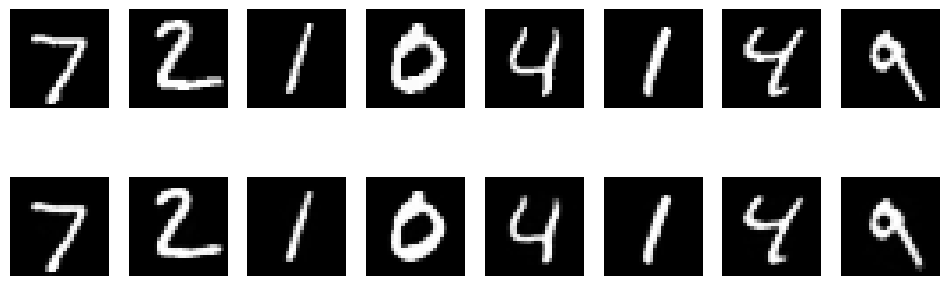

In [ ]:
# OVERCOMPLETE AUTOENCODER

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Load data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Model (expand to 1024)
input_img = Input(shape=(784,))
encoded = Dense(1024, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train, epochs=5, batch_size=256)

decoded_imgs = autoencoder.predict(x_test)

# Show results
n = 8
plt.figure(figsize=(12,4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3997
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2361
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2145
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2032
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1952
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


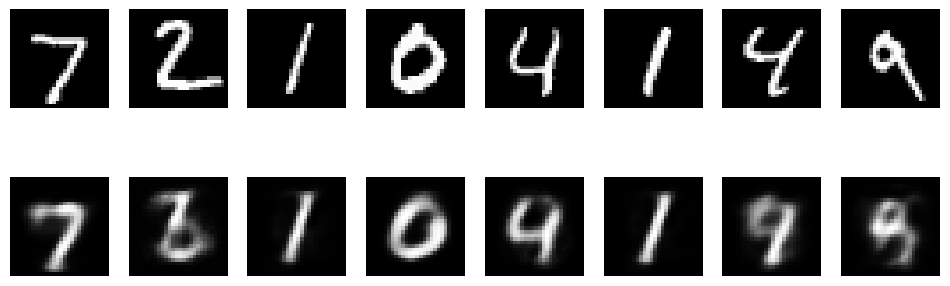

In [ ]:
# REGULARIZED AUTOENCODER

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

# Load data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Model with L1 regularization
input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train, epochs=5, batch_size=256)

decoded_imgs = autoencoder.predict(x_test)

# Show results
n = 8
plt.figure(figsize=(12,4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.2326
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1513
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1336
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1249
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


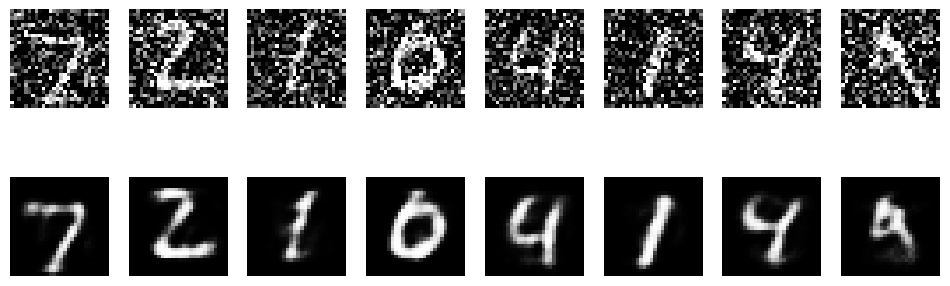

In [ ]:
# DENOISING AUTOENCODER

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Load data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Add noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Model
input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train_noisy, x_train, epochs=5, batch_size=256)

decoded_imgs = autoencoder.predict(x_test_noisy)

# Show results (noisy vs reconstructed)
n = 8
plt.figure(figsize=(12,4))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()